# 05 — Logistic Regression: Classifying High vs Low Rating
**Project:** Audible Audiobook Analytics  
**Team:** Team Mars  
**Author:** Nirwan Maharjan  
**Week:** 5  

This notebook builds and validates the logistic regression model.  
Input: `../data/model_ready.csv`  
Output: `../models/rating_model.pkl`

### Steps
1. Load data & define features
2. Train/test split
3. Scale features
4. Fit the model (statsmodels — for p-values & odds ratios)
5. Interpret coefficients & test hypotheses
6. Evaluate: confusion matrix, classification report
7. ROC curve & AUC
8. Save model

---
## 1. Load Data & Define Features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs/plots', exist_ok=True)

df = pd.read_csv('../data/model_ready.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (87419, 18)


,star_score,lang_Japanese,lang_Spanish,release_year,is_top_author,lang_German,lang_Italian,lang_Other,duration_minutes,price,is_top_narrator,log_num_ratings,price.1,high_rating,star_score.1,name,author,narrator
0,4.5,False,False,1998,0,False,False,False,691.00,773.0,0,5.796058,773.0,1,4.5,"Surely You're Joking, Mr. Feynman!",Richard P.Feynman,Raymond Todd
1,4.5,False,False,1998,0,False,False,False,568.00,1407.0,0,5.117994,1407.0,1,4.5,"Men Are from Mars, Women Are from Venus",John Gray,John Gray
2,5.0,False,False,1998,0,False,False,False,78.00,233.0,0,1.098612,233.0,1,5.0,Letters to a Young Poet,"Rainer Maria Rilke,Stephen Mitchell-translator",Stephen Mitchell
3,0.0,False,False,1999,0,False,False,False,808.00,773.0,0,0.000000,773.0,0,0.0,"Rhetoric, Poetics and Logic",Aristotle,Frederick Davidson
4,0.0,False,False,1999,0,False,False,False,1656.82,1338.0,0,0.000000,1338.0,0,0.0,Wealth of Nations,Adam Smith,Michael Edwards


In [2]:
lang_cols = [c for c in df.columns if c.startswith('lang_')]

features = (
    ['price', 'duration_minutes', 'log_num_ratings',
     'release_year', 'is_top_narrator', 'is_top_author']
    + lang_cols
)
target = 'high_rating'

X = df[features]
y = df[target]

print(f'Features ({len(features)}): {features}')
print(f'X shape: {X.shape} | y shape: {y.shape}')
print(f'\nClass distribution:')
print(y.value_counts())
print(f'Class balance: {y.mean()*100:.1f}% high-rated')

Features (11): ['price', 'duration_minutes', 'log_num_ratings', 'release_year', 'is_top_narrator', 'is_top_author', 'lang_Japanese', 'lang_Spanish', 'lang_German', 'lang_Italian', 'lang_Other']
X shape: (87419, 11) | y shape: (87419,)

Class distribution:
high_rating
0    73925
1    13494
Name: count, dtype: int64
Class balance: 15.4% high-rated


---
## 2. Train / Test Split

In [3]:
# stratify=y ensures both classes are proportionally represented
# in both the training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]} rows')
print(f'Test set:      {X_test.shape[0]} rows')
print(f'\nClass balance in training set: {y_train.mean()*100:.1f}% high-rated')
print(f'Class balance in test set:     {y_test.mean()*100:.1f}% high-rated')

Training set:  69935 rows
Test set:      17484 rows

Class balance in training set: 15.4% high-rated
Class balance in test set:     15.4% high-rated


---
## 3. Scale Features

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=features)

print('Scaling complete.')

Scaling complete.


---
## 4. Fit the Model with Statsmodels

Using statsmodels `Logit` to get p-values and confidence intervals  
for formal hypothesis testing.

In [5]:
X_train_sm = sm.add_constant(X_train_scaled)

logit_model = sm.Logit(y_train.values, X_train_sm).fit(maxiter=200)

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.094006
         Iterations 34
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                69935
Model:                          Logit   Df Residuals:                    69923
Method:                           MLE   Df Model:                           11
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.7815
Time:                        14:29:11   Log-Likelihood:                -6574.3
converged:                       True   LL-Null:                       -30086.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -4.4343   7.02e+05  -6.32e-06      1.000   -1.38e+06    1.38e+06
price     

---
## 5. Interpret Coefficients, Odds Ratios & Test Hypotheses

In logistic regression, the raw coefficients are **log-odds**.  
We exponentiate them to get **odds ratios**, which are easier to interpret:  
- Odds ratio > 1 → feature increases the probability of high rating  
- Odds ratio < 1 → feature decreases the probability of high rating  
- Odds ratio = 1 → feature has no effect

In [6]:
coef_df = pd.DataFrame({
    'Feature':     ['const'] + features,
    'Log-Odds':    logit_model.params.values,
    'Odds Ratio':  np.exp(logit_model.params.values),
    'p-value':     logit_model.pvalues.values,
    'Significant': logit_model.pvalues.values < 0.05
})

coef_df = coef_df[coef_df['Feature'] != 'const'].sort_values('p-value')
coef_df.round(4)

,Feature,Log-Odds,Odds Ratio,p-value,Significant
3,log_num_ratings,5.1879,179.0970,0.0000,True
11,lang_Other,-0.4305,0.6502,0.0000,True
9,lang_German,-0.6088,0.5440,0.0000,True
8,lang_Spanish,-0.4696,0.6252,0.0000,True
4,release_year,-0.1030,0.9021,0.0000,True
10,lang_Italian,-0.6656,0.5140,0.0003,True
1,price,0.1194,1.1268,0.0004,True
6,is_top_author,-0.0628,0.9391,0.1187,False
5,is_top_narrator,-0.0340,0.9666,0.2980,False
2,duration_minutes,0.0204,1.0206,0.5138,False


In [7]:
# Hypothesis test summary
print('=== Hypothesis Test Results (α = 0.05) ===')
print(f'{"Feature":<22} {"Odds Ratio":>12} {"p-value":>10}   Decision')
print('-' * 70)
for _, row in coef_df.iterrows():
    decision = 'REJECT H₀ ✓' if row['Significant'] else 'Fail to reject H₀'
    print(f"{row['Feature']:<22} {row['Odds Ratio']:>12.4f} {row['p-value']:>10.4f}   {decision}")

=== Hypothesis Test Results (α = 0.05) ===
Feature                  Odds Ratio    p-value   Decision
----------------------------------------------------------------------
log_num_ratings            179.0970     0.0000   REJECT H₀ ✓
lang_Other                   0.6502     0.0000   REJECT H₀ ✓
lang_German                  0.5440     0.0000   REJECT H₀ ✓
lang_Spanish                 0.6252     0.0000   REJECT H₀ ✓
release_year                 0.9021     0.0000   REJECT H₀ ✓
lang_Italian                 0.5140     0.0003   REJECT H₀ ✓
price                        1.1268     0.0004   REJECT H₀ ✓
is_top_author                0.9391     0.1187   Fail to reject H₀
is_top_narrator              0.9666     0.2980   Fail to reject H₀
duration_minutes             1.0206     0.5138   Fail to reject H₀
lang_Japanese                0.0004     1.0000   Fail to reject H₀


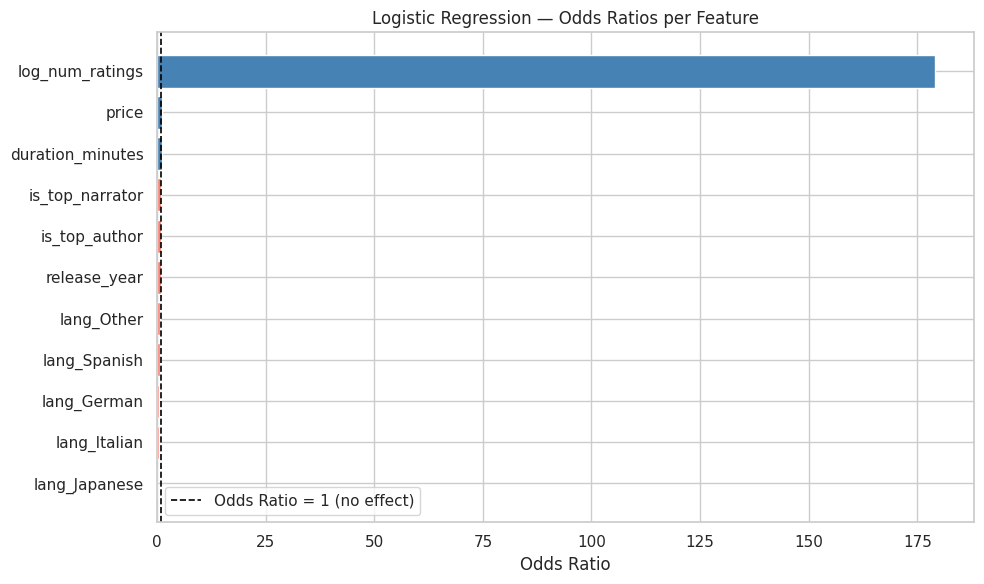

In [8]:
# Odds ratio plot — intuitive visual of each feature's effect direction
plot_df = coef_df.sort_values('Odds Ratio').copy()
colors  = ['steelblue' if v >= 1 else 'salmon' for v in plot_df['Odds Ratio']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df['Feature'], plot_df['Odds Ratio'], color=colors)
ax.axvline(1, color='black', linewidth=1.2, linestyle='--', label='Odds Ratio = 1 (no effect)')
ax.set_title('Logistic Regression — Odds Ratios per Feature')
ax.set_xlabel('Odds Ratio')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/logistic_odds_ratios.png', dpi=150)
plt.show()

**How to read this chart:**  
Bars to the right of 1 increase the odds of a high rating.  
Bars to the left of 1 decrease the odds.  
The further from 1, the stronger the effect.

**Write your observation here:** *(e.g. 'log_num_ratings has an odds ratio of X, meaning books with more reviews are X times more likely to be highly rated. is_top_narrator shows an odds ratio of Y...')*

---
## 6. Evaluate: Confusion Matrix & Classification Report

In [9]:
# Use sklearn model for predictions
sk_logit = LogisticRegression(max_iter=500, random_state=42)
sk_logit.fit(X_train_scaled, y_train)

y_pred       = sk_logit.predict(X_test_scaled)
y_pred_proba = sk_logit.predict_proba(X_test_scaled)[:, 1]

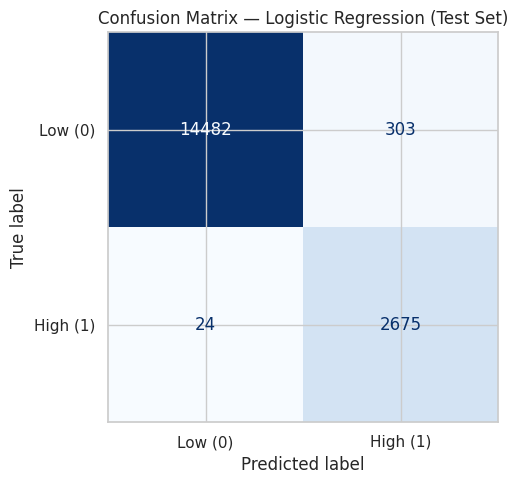

True Positives  (predicted High, actually High): 2675
True Negatives  (predicted Low,  actually Low):  14482
False Positives (predicted High, actually Low):  303
False Negatives (predicted Low,  actually High): 24


In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low (0)', 'High (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression (Test Set)')
plt.tight_layout()
plt.savefig('../outputs/plots/confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (predicted High, actually High): {tp}')
print(f'True Negatives  (predicted Low,  actually Low):  {tn}')
print(f'False Positives (predicted High, actually Low):  {fp}')
print(f'False Negatives (predicted Low,  actually High): {fn}')

In [11]:
# Full classification report
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Low Rating (0)', 'High Rating (1)']))

=== Classification Report ===
                 precision    recall  f1-score   support

 Low Rating (0)       1.00      0.98      0.99     14785
High Rating (1)       0.90      0.99      0.94      2699

       accuracy                           0.98     17484
      macro avg       0.95      0.99      0.97     17484
   weighted avg       0.98      0.98      0.98     17484



**Metrics explained:**
- **Accuracy** — overall % of correct predictions
- **Precision** — of all books predicted High, what % actually are High?
- **Recall** — of all books that actually are High, what % did we catch?
- **F1-score** — harmonic mean of precision and recall; useful when classes are imbalanced

**Write your observation here:** *(e.g. 'The model achieves X% accuracy. Precision for high-rating class is X%, meaning X% of predicted high books are genuinely high-rated.')*

---
## 7. ROC Curve & AUC

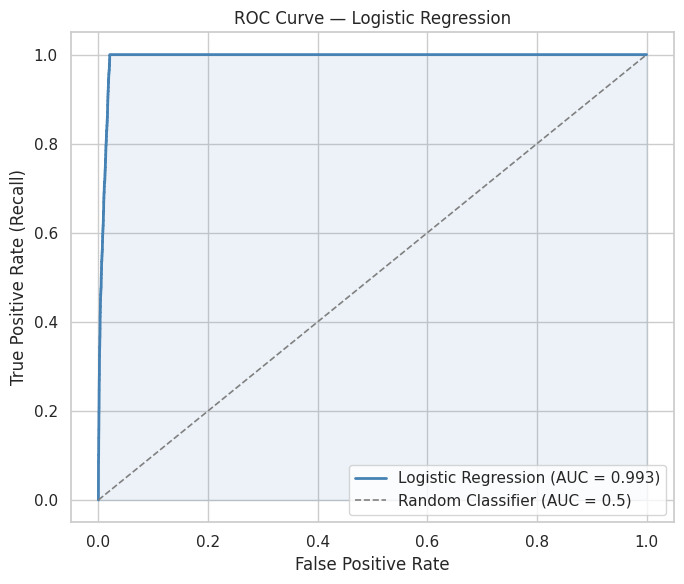

AUC Score: 0.9928
✓ AUC ≥ 0.8 — Good discriminative ability


In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'Logistic Regression (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1.2, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_title('ROC Curve — Logistic Regression')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/plots/roc_curve.png', dpi=150)
plt.show()

print(f'AUC Score: {auc_score:.4f}')
if auc_score >= 0.8:
    print('✓ AUC ≥ 0.8 — Good discriminative ability')
elif auc_score >= 0.7:
    print('✓ AUC ≥ 0.7 — Acceptable discriminative ability')
else:
    print('⚠️  AUC < 0.7 — Model struggles to separate classes')

**How to read the ROC curve:**  
The curve shows the trade-off between True Positive Rate and False Positive Rate at every possible classification threshold.  
A perfect model would hit the top-left corner (TPR=1, FPR=0). The diagonal dashed line represents a random guess.  
AUC (Area Under the Curve): 0.5 = no better than random, 1.0 = perfect.

**Write your observation here:** *(e.g. 'The AUC of X indicates the model has good/acceptable ability to distinguish high-rated from low-rated audiobooks.')*

In [13]:
# Summary of all metrics in one place
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('=== Full Model Performance Summary ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred):.4f}')
print(f'AUC:       {auc_score:.4f}')

=== Full Model Performance Summary ===
Accuracy:  0.9813
Precision: 0.8983
Recall:    0.9911
F1-Score:  0.9424
AUC:       0.9928


---
## 8. Save Model

In [14]:
joblib.dump(sk_logit,  '../models/rating_model.pkl')
joblib.dump(scaler,    '../models/rating_scaler.pkl')
joblib.dump(features,  '../models/logistic_features.pkl')

print('Saved:')
print('  ../models/rating_model.pkl')
print('  ../models/rating_scaler.pkl')
print('  ../models/logistic_features.pkl')

Saved:
  ../models/rating_model.pkl
  ../models/rating_scaler.pkl
  ../models/logistic_features.pkl
